# Land use replaces density — proof of concept

`density` is retired. A block is a mix of three **sectors**, each with its own temporal signature:

| sector | daily | weekly | night | weather |
|---|---|---|---|---|
| residential | 3 use peaks | weekend shift + damp | low floor | full |
| commercial  | work-hours plateau | near-closed Sat/Sun | ~0 | weak |
| industrial  | 24/7 with day lift | mild weekend dip | high | none |

Level comes from a per-plot intensity table, dialled by `beta`: `0.0` = shape-only
(volume-neutral, hydraulically safe), `1.0` = full level effect.

Nothing in `src/` is modified — `build_portfolios`, `evolve_assignments` and
`synthesize_demands` are overridden here.

## 0. Setup

In [1]:
%matplotlib inline
import copy, itertools, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.special import erf

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parents[1]          # notebooks/prospection -> repo root

from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession
bootstrap_project(ROOT)
with KedroSession.create(project_path=ROOT) as session:
    ctx = session.load_context()
    CATALOG, PARAMS = ctx.catalog, ctx.params

WN_RAW    = CATALOG.load("graeme_network")
DISTRICTS = CATALOG.load("districts")
NODE2DIST = {n: d for d, ns in DISTRICTS["districts"].items() for n in ns}

from fedwater.pipelines.network_prep.nodes import configure_network, apply_coupling
from fedwater.pipelines.urban_scenario.nodes import (
    build_income_factors, build_drift_schedule, SECONDS_PER_DAY, ANCHOR_DAYS_PER_MONTH)
from fedwater.pipelines.demand_synthesis.nodes import apply_drift_ramp
from fedwater.pipelines.hydraulics.nodes import run_hydraulics

INC = build_income_factors(PARAMS["buildings"])
INC

[08/28/26 18:48:48] INFO     Using                                                                  ]8;id=16089;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=743117;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[08/28/26 18:48:54] INFO     No typed parameter requirements found, returning original   ]8;id=119708;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=77673;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=957479;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=696013;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[08/28/26 18:48:55] INFO     Loading data from graeme_network (WntrNetworkDataset)...          ]8;id=797712;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=316571;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from districts (YAMLDataset)...                      ]8;id=144319;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=269336;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

,income,mean_unit_m3_month,income_factor
0,low,1.45,0.527273
1,medium,2.75,1.000000
2,high,7.05,2.563636


## 1. Sector table

`intensity_rel` = m3/month drawn by one plot of that sector, in units of one *medium-income*
residential unit. Residential intensity is not free — it is `mean_unit_m3_month(income)` from the
existing standards table. Only the two non-residential numbers are new assumptions.

`land_use_mix` = share of a block's plots in each sector. Level and shape both follow from it.

In [2]:
SECTORS = {
    "residential": dict(
        kind="peaks", night=0.15, dispersion_h=0.9, weekend_factor=1.0,
        day_sigma=0.12, seasonal_amplitude=0.14,
        peaks={"morning": (7.0, 3.5), "afternoon": (14.0, 1.0), "evening": (19.0, 3.5)}),
    "commercial": dict(
        kind="plateau", window=(8.0, 18.0), night=0.03, amp=1.00, dispersion_h=0.8,
        weekend_factor=0.15, day_sigma=0.05, seasonal_amplitude=0.06),
    "industrial": dict(
        kind="plateau", window=(6.0, 22.0), night=0.85, amp=0.22, dispersion_h=0.5,
        weekend_factor=0.90, day_sigma=0.02, seasonal_amplitude=0.01),
}

INTENSITY_REL = {"commercial": 3.0, "industrial": 9.0}   # x one medium-income unit

LAND_USE_MIX = {                                          # plot shares
    "residential": {"residential": 1.00},
    "mixed":       {"residential": 0.70, "commercial": 0.28, "industrial": 0.02},
    "commercial":  {"residential": 0.35, "commercial": 0.60, "industrial": 0.05},
    "industrial":  {"residential": 0.30, "commercial": 0.15, "industrial": 0.55},
}

_INC_C = {"L": "low", "M": "medium", "H": "high"}
_LU_C  = {"R": "residential", "M": "mixed", "C": "commercial", "I": "industrial"}

def decode_landuse_map(code: str, n_districts: int = 5) -> list[list[str]]:
    """'LR_LM_LC_LR_LR' -> [[income, land_use], ...] in district order A.."""
    toks = code.strip().upper().split("_")
    assert len(toks) == n_districts, f"{code}: expected {n_districts} tokens"
    return [[_INC_C[t[0]], _LU_C[t[1]]] for t in toks]

In [3]:
def plot_intensity(income: str) -> dict:
    """m3/month per plot, by sector, for a given residential income class."""
    med = INC.set_index("income")["mean_unit_m3_month"]["medium"]
    res = INC.set_index("income")["mean_unit_m3_month"][income]
    return {"residential": res, **{s: r * med for s, r in INTENSITY_REL.items()}}


def build_landuse_factors(beta: float = 1.0, reference=("low", "residential")) -> pd.DataFrame:
    """Level factor per (income, land_use): plot-count conserved, dialled by beta."""
    def mean_plot(income, mix):
        I = plot_intensity(income)
        return sum(w * I[s] for s, w in LAND_USE_MIX[mix].items())
    ref = mean_plot(*reference)
    rows = [{"income": inc, "land_use": lu, "mean_plot_m3_month": mean_plot(inc, lu),
             "level_factor": (mean_plot(inc, lu) / ref) ** beta}
            for inc in INC["income"] for lu in LAND_USE_MIX]
    return pd.DataFrame(rows)


build_landuse_factors(1.0).query("income == 'low'").round(3)

,income,land_use,mean_plot_m3_month,level_factor
0,low,residential,1.450,1.000
1,low,mixed,3.820,2.634
2,low,commercial,6.695,4.617
3,low,industrial,15.285,10.541


## 2. Sector shapes

A plateau is a boxcar convolved with the same Gaussian start-time jitter that residential peaks
use, so it stays a difference of two erfs and crowd smoothing remains *derived* (`1/sqrt(N)`).
Establishments are few per block, so commercial and industrial cohorts are naturally noisier.

In [4]:
def _gauss(t, mu, w):  return np.exp(-0.5 * ((t - mu) / w) ** 2)
def _boxcar(t, a, b, w): return 0.5 * (erf((t - a) / (np.sqrt(2) * w))
                                       - erf((t - b) / (np.sqrt(2) * w)))


def sector_day_shape(t, sector, units, rng, weekend, patterns):
    """One sector cohort's daily shape, arbitrary scale, >= 0."""
    p = SECTORS[sector]
    w_eff = np.sqrt(patterns["peak_width_h"] ** 2 + p["dispersion_h"] ** 2)
    resid = 1.0 / np.sqrt(max(units, 1.0))
    jit   = rng.normal(0.0, p["dispersion_h"] * resid)
    amp_n = lambda a: max(a * (1.0 + rng.normal(0.0, patterns["amp_sigma"] * resid)), 0.0)

    if p["kind"] == "peaks":
        shape = np.full_like(t, p["night"], dtype=float)
        shift = patterns["weekend_morning_shift_h"] if weekend else 0.0
        for name, (mu, amp) in p["peaks"].items():
            a = amp_n(amp) * (patterns["weekend_morning_damp"]
                              if (weekend and name == "morning") else 1.0)
            shape += a * _gauss(t, mu + jit + (shift if name == "morning" else 0.0), w_eff)
    else:
        a, b = p["window"]
        shape = p["night"] + amp_n(p["amp"]) * _boxcar(t, a + jit, b + jit, w_eff)

    if weekend:
        shape = shape * p["weekend_factor"]
    return np.clip(shape, 1e-6, None)

In [5]:
_t = np.arange(24) + .5
fig, axes = plt.subplots(1, 3, figsize=(12, 2.9), sharey=True)
for ax, s in zip(axes, SECTORS):
    for units, ls in ((400, "-"), (8, ":")):
        wk = np.concatenate([sector_day_shape(_t, s, units, np.random.default_rng(d),
                                              d % 7 >= 5, PARAMS["patterns"]) for d in range(7)])
        ax.plot(np.arange(len(wk)) / 24, wk / wk.mean(), ls, lw=1.4, label=f"N={units}")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(title=s, xlabel="day of week")
    ax.legend(fontsize=7)
axes[0].set_ylabel("normalised demand")
plt.tight_layout()

## 3. POC portfolios (sectors replace density cohorts)

In [6]:
def _plots(node, district, income, land_use, anchor, volume):
    """Split a node's volume into sector cohorts. Plot counts are exact by construction."""
    I = plot_intensity(income)
    mix = LAND_USE_MIX[land_use]
    mean_plot = sum(w * I[s] for s, w in mix.items())
    total = volume / mean_plot
    out = []
    for s, w in mix.items():
        n = float(total * w)
        if n < 0.5:
            continue
        out.append({"node": node, "district": district, "income": income,
                    "land_use": land_use, "sector": s, "plots": n,
                    "sector_volume_m3_month": n * I[s],
                    "anchor_m3_month": anchor, "volume_m3_month": volume})
    return out


def poc_build_portfolios(wn, districts, landuse_factors, scenario, hydraulics, seed):
    mapping = dict(zip(districts["districts"].keys(), scenario["income_land_use_mapping"]))
    lvl = landuse_factors.set_index(["income", "land_use"])["level_factor"].to_dict()
    rows = []
    for district, nodes in districts["districts"].items():
        income, land_use = mapping[district]
        for node in nodes:
            base_si = wn.get_node(node).demand_timeseries_list[0].base_value
            anchor  = base_si * hydraulics["anchor_scale"] * SECONDS_PER_DAY * ANCHOR_DAYS_PER_MONTH
            rows += _plots(node, district, income, land_use, anchor,
                           anchor * lvl[(income, land_use)])
    df = pd.DataFrame(rows)
    per_node = df.drop_duplicates("node")
    calib = per_node["anchor_m3_month"].sum() / per_node["volume_m3_month"].sum()
    for c in ("volume_m3_month", "sector_volume_m3_month", "plots"):
        df[c] *= calib
    df["calibration"] = calib
    return df


def poc_evolve_assignments(portfolios_t0, drift_schedule, landuse_factors, scenario):
    lvl   = landuse_factors.set_index(["income", "land_use"])["level_factor"].to_dict()
    ds    = drift_schedule.set_index("node")
    calib = portfolios_t0["calibration"].iloc[0]
    frames = []
    for month in range(scenario["n_months"]):
        snap   = portfolios_t0.copy()
        switch = ds.index[ds["drift_month"] <= month].tolist()
        if switch:
            base, new = snap[snap["node"].isin(switch)].drop_duplicates("node"), []
            for _, r in base.iterrows():
                to_i, to_l = ds.loc[r["node"], "to_income"], ds.loc[r["node"], "to_land_use"]
                anchor = r["anchor_m3_month"]
                new += _plots(r["node"], r["district"], to_i, to_l, anchor,
                              anchor * calib * lvl[(to_i, to_l)])
            snap = pd.concat([snap[~snap["node"].isin(switch)],
                              pd.DataFrame(new).assign(calibration=calib)], ignore_index=True)
        frames.append(snap.assign(month=month))
    return pd.concat(frames, ignore_index=True)

## 4. POC demand synthesis

Two corrections the sector model forces:

1. cohorts are mixed by **volume share**, not plot count — sectors differ ~10x in intensity;
2. each cohort is normalised over the **whole month**, not per day, so commercial's weekend
   collapse survives the mixing.

Seasonality and the common-mode weather factor become volume-weighted across sectors.

In [7]:
def poc_synthesize_demands(assignments_timeline, patterns, time, seed):
    res_h, days, n_months = time["resolution_h"], time["days_per_month"], time["n_months"]
    steps = int(round(24 / res_h))
    t = (np.arange(steps) + 0.5) * res_h
    nodes = sorted(assignments_timeline["node"].unique(), key=int)
    out = np.zeros((n_months * days * steps, len(nodes)))

    for (month, node), coh in assignments_timeline.groupby(["month", "node"]):
        rng   = np.random.default_rng([seed, int(month), int(node)])
        month = int(month)
        vol_w = (coh.set_index("sector")["sector_volume_m3_month"]
                 / coh["sector_volume_m3_month"].sum())
        wknd  = np.array([((month * days + d) % 7) >= 5 for d in range(days)])

        node_series = np.zeros(days * steps)
        for sector, w in vol_w.items():
            n_plots = float(coh.set_index("sector")["plots"][sector])
            s = np.concatenate([sector_day_shape(t, sector, n_plots, rng, bool(wk), patterns)
                                for wk in wknd])
            node_series += w * (s / s.mean())            # month-normalised, volume-weighted

        seas_a = patterns.get("seasonality_scale", 1.0) * sum(
            w * SECTORS[s]["seasonal_amplitude"] for s, w in vol_w.items())
        day_s  = sum(w * SECTORS[s]["day_sigma"] for s, w in vol_w.items())
        node_series *= np.repeat(1.0 + rng.normal(0.0, day_s, days), steps)   # common mode

        v_month = (coh["sector_volume_m3_month"].sum()
                   * (1.0 + seas_a * np.cos(2 * np.pi * (month % 12
                        - patterns["seasonal_peak_month"]) / 12.0))
                   * rng.lognormal(0.0, patterns["month_sigma"]))
        liters = v_month * 1000.0 * days / ANCHOR_DAYS_PER_MONTH
        node_series = np.clip(node_series, 1e-9, None)
        lps = node_series / (node_series.sum() * res_h * 3600.0) * liters

        i, j = month * days * steps, nodes.index(node)
        out[i:i + days * steps, j] = lps

    df = pd.DataFrame(out, columns=nodes)
    df["month"] = np.repeat(np.arange(n_months), days * steps)
    return df

## 5. World runner

In [13]:
CFG = dict(n_months=10, days_per_month=14, resolution_h=1, anchor_scale=0.05,
           beta=0.35, drift_ramp_days=42, warmup_months=2, sim_seed=42,
           seasonality_scale=0.0)   # 0 = off: seasonality confounds before/after level

def pick_seed_node(wn, district: str) -> str:
    """Largest-base-demand junction in the district, skipping zero-demand trunk nodes."""
    base = {n: wn.get_node(n).demand_timeseries_list[0].base_value
            for n in DISTRICTS["districts"][district]}
    nz = {n: v for n, v in base.items() if v > 0}
    return max(nz or base, key=(nz or base).get)   

def run_world(map_code: str, drifts: list[dict], **over):
    cfg  = {**CFG, **over}
    p    = copy.deepcopy(PARAMS)
    time = {k: cfg[k] for k in ("n_months", "days_per_month", "resolution_h")}
    hyd  = {**p["hydraulics"], "anchor_scale": cfg["anchor_scale"]}
    pat  = {**p["patterns"], "drift_ramp_days": cfg["drift_ramp_days"],
            "seasonality_scale": cfg["seasonality_scale"]}
    scen = {**p["scenario"], "n_months": cfg["n_months"],
            "income_land_use_mapping": decode_landuse_map(map_code)}

    wn = configure_network(copy.deepcopy(WN_RAW), hyd, time)
    wn, _ = apply_coupling(wn, DISTRICTS, p["coupling"], seed=cfg["sim_seed"])

    lf = build_landuse_factors(cfg["beta"])
    pf = poc_build_portfolios(wn, DISTRICTS, lf, scen, hyd, cfg["sim_seed"])

    # build_drift_schedule is reused unchanged: land use rides in the to_density slot.
    sched = pd.concat([
        build_drift_schedule(
            wn, DISTRICTS,
            {**scen, "drift": {**scen["drift"], "tgt_district": d["tgt_district"],
                               "to_income": d["to_income"], "to_density": d["to_land_use"],
                               "seed_node": d.get("seed_node") or pick_seed_node(wn, d["tgt_district"]), "warmup_months": cfg["warmup_months"]}},
            seed=cfg["sim_seed"] + i)
        for i, d in enumerate(drifts)], ignore_index=True)
    
    sched = sched.rename(columns={"to_density": "to_land_use"})

    avail = (cfg["n_months"] - int(sched["drift_month"].max())) * cfg["days_per_month"]
    pat = {**p["patterns"], "seasonality_scale": cfg["seasonality_scale"],
           "drift_ramp_days": min(cfg["drift_ramp_days"], max(avail - 1, 1))}

    tl  = poc_evolve_assignments(pf, sched, lf, scen)
    dem = apply_drift_ramp(poc_synthesize_demands(tl, pat, time, cfg["sim_seed"]),
                           sched, pat, time)
    pres, flows, _ = run_hydraulics(wn, dem)
    return dict(map=map_code, drifts=drifts, beta=cfg["beta"], cfg=cfg, time=time,
                calibration=float(pf["calibration"].iloc[0]), schedule=sched,
                timeline=tl, demand=dem, pressures=pres, flows=flows)

In [14]:
BASE = [{"tgt_district": "District_D", "to_income": "low", "to_land_use": "commercial"}]

res_lvl = run_world("LR_LM_LC_LR_LR", BASE, beta=0.35)   # shape + level
res_shp = run_world("LR_LM_LC_LR_LR", BASE, beta=0.0)   # shape only (volume-neutral)

print(f"calibration  beta=0.35: {res_lvl['calibration']:.3f}   beta=0: {res_shp['calibration']:.3f}")
res_lvl["schedule"].head()

calibration  beta=0.35: 0.820   beta=0: 1.000


,node,district,drift_month,to_income,to_land_use
0,89,District_D,2,low,commercial
1,25,District_D,3,low,commercial
2,26,District_D,4,low,commercial
3,33,District_D,6,low,commercial
4,85,District_D,6,low,commercial


## 6. Before / during / after

In [25]:
def _cols(r):  return [c for c in r["demand"].columns if c != "month"]
def _steps(r): return int(round(24 / r["time"]["resolution_h"]))
def _tgt(r):   return [d["tgt_district"] for d in r["drifts"]]
def _onset(r): return int(r["schedule"]["drift_month"].min())
def _end(r):   return int(r["schedule"]["drift_month"].max())
def _nodes(r): return sorted({n for d in _tgt(r) for n in DISTRICTS["districts"][d]
                              if n in r["demand"].columns})

def phases(r):
    o, e, n = _onset(r), _end(r), r["time"]["n_months"]
    return {"before": max(o - 1, 0), "during": min((o + e) // 2 + 1, n - 1), "after": n - 1}

def _daily(r, series):
    """(n_days, steps) view of a node-summed series, plus each day's global index."""
    st, dpm = _steps(r), r["time"]["days_per_month"]
    day = series.to_numpy().reshape(-1, st)
    month_of_day = r["demand"]["month"].to_numpy()[::st]
    gday = month_of_day * dpm + np.tile(np.arange(dpm), r["time"]["n_months"])
    return day, month_of_day, gday


def week_profile(r, month, nodes=None, scaled=False, ref_months=2):
    """Mean 7-day profile for one month. scaled=True applies per-client MinMax
    fitted on the reference months, exactly as the FL preprocessing does."""
    s = r["demand"][nodes or _nodes(r)].sum(axis=1)
    if scaled:
        ref = s[r["demand"]["month"] < ref_months]
        s = (s - ref.min()) / (ref.max() - ref.min())
    day, mod, gday = _daily(r, s)
    sel = mod == month
    prof = []
    for w in range(7):
        m = sel & (gday % 7 == w)
        prof.append(day[m].mean(0) if m.any() else day[sel].mean(0))
    return np.concatenate(prof)

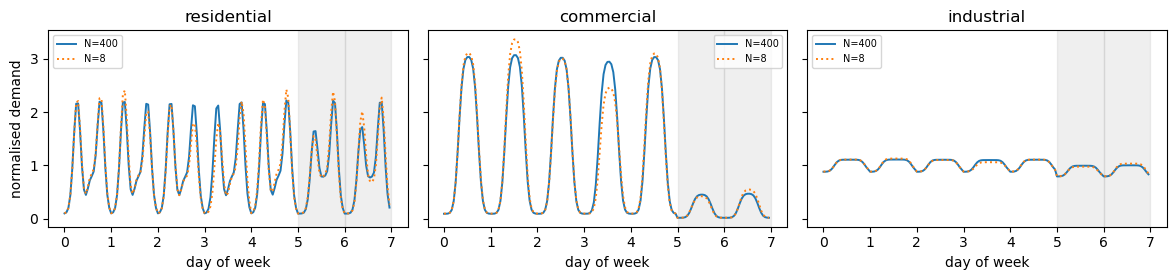

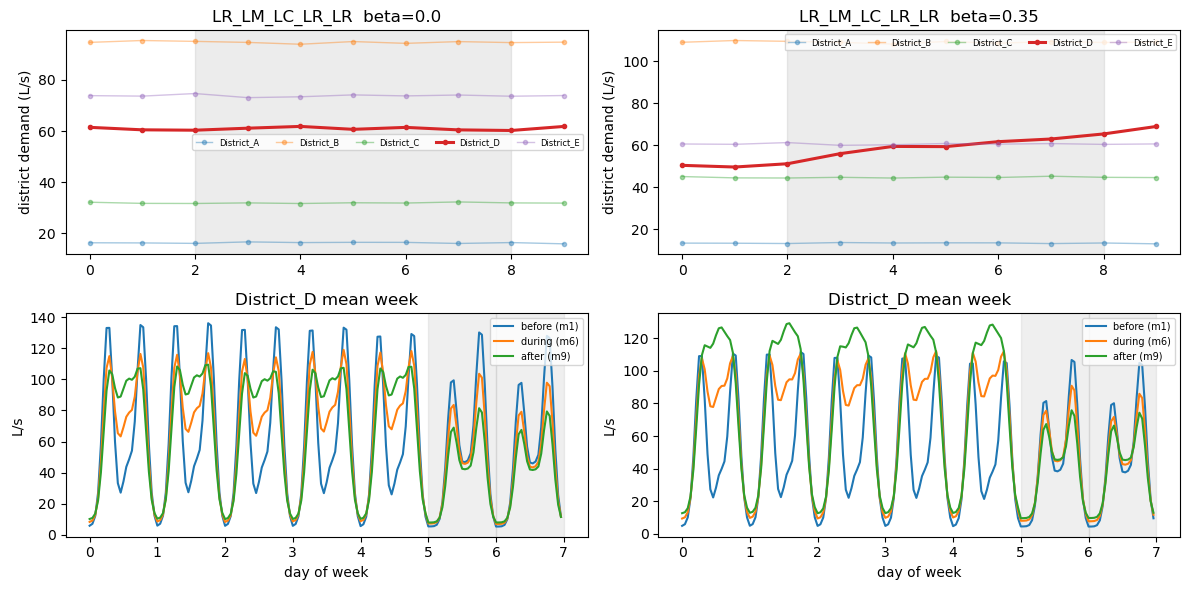

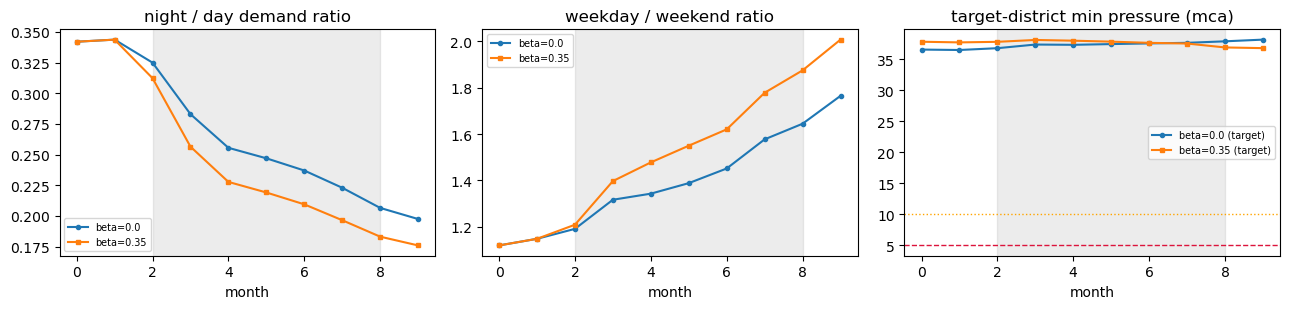

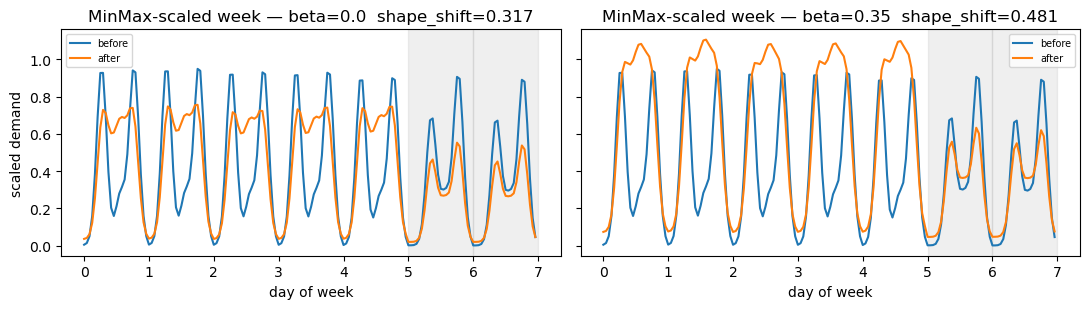

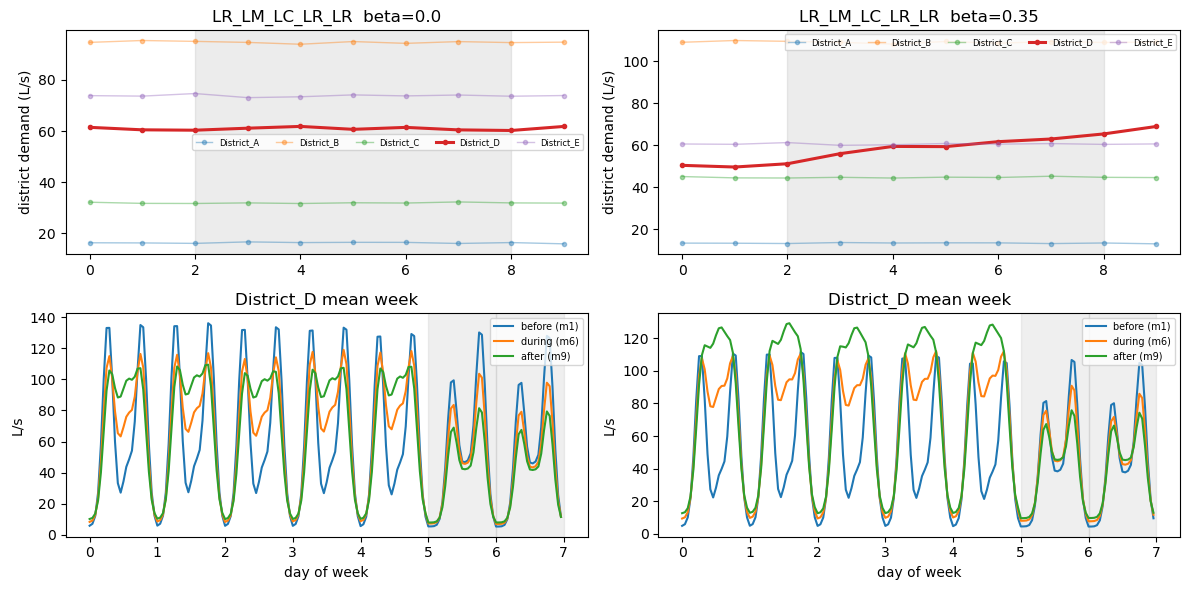

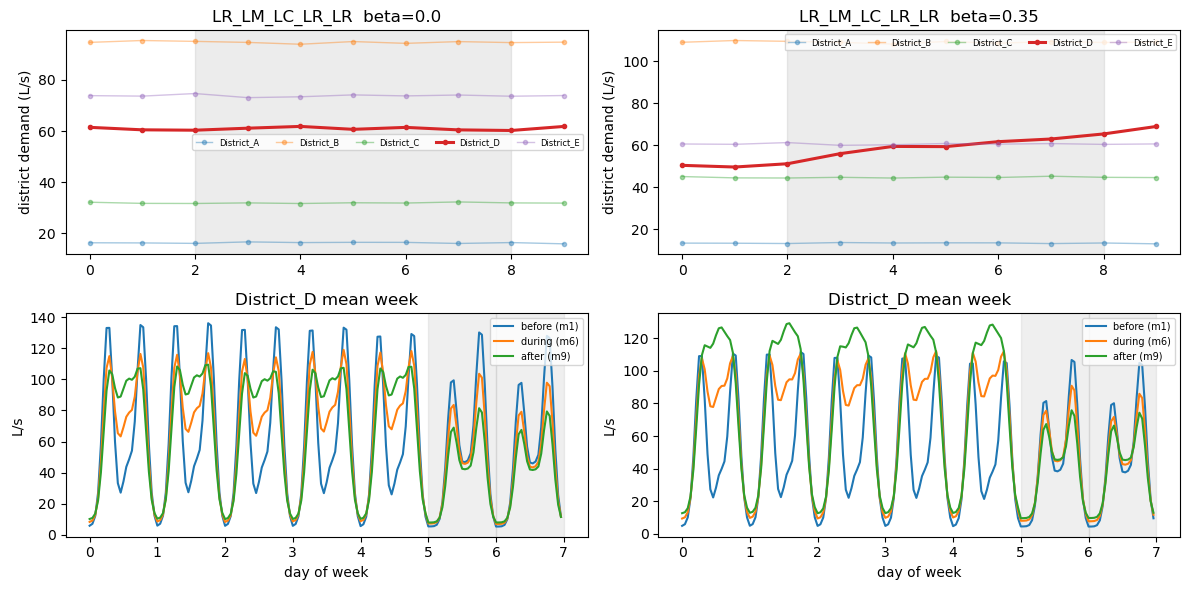

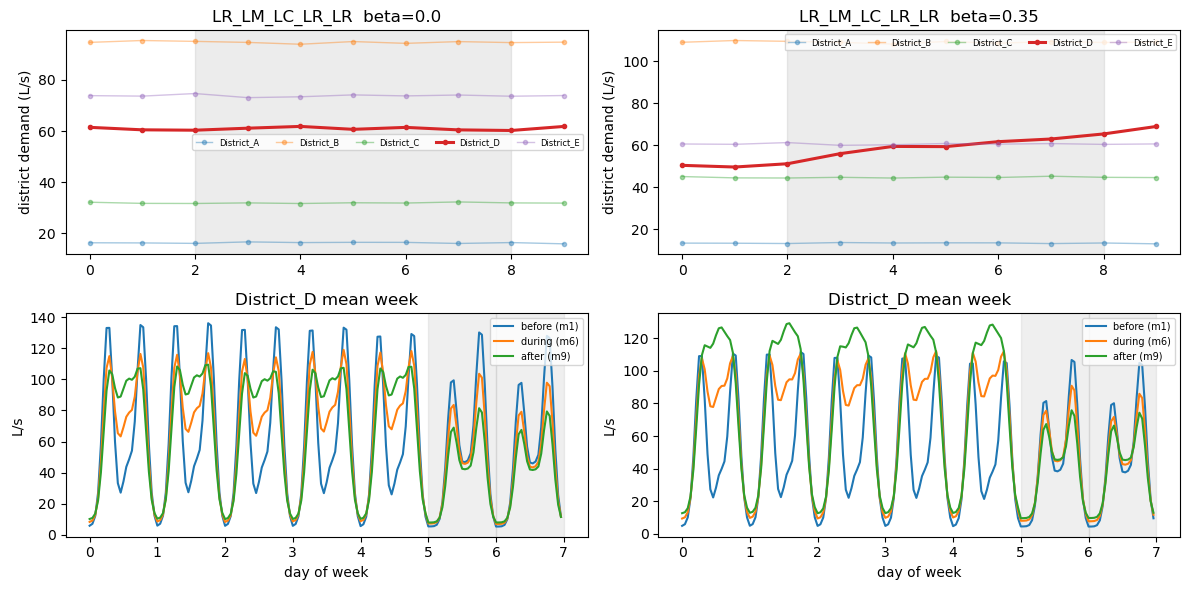

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for col, r in enumerate((res_shp, res_lvl)):
    ax = axes[0, col]
    m = r["demand"].groupby("month")[_cols(r)].mean()
    for dist, ns in DISTRICTS["districts"].items():
        ns = [n for n in ns if n in m.columns]
        tgt = dist in _tgt(r)
        ax.plot(m.index, m[ns].sum(axis=1), marker="o", ms=3, label=dist,
                lw=2.2 if tgt else 1.0, alpha=1.0 if tgt else .4)
    ax.axvspan(_onset(r), _end(r), color="grey", alpha=.15, zorder=0)
    ax.set(ylabel="district demand (L/s)", title=f"{r['map']}  beta={r['beta']}")
    ax.legend(fontsize=6, ncol=5)

    ax = axes[1, col]
    for name, mth in phases(r).items():
        ax.plot(np.arange(7 * _steps(r)) / _steps(r), week_profile(r, mth),
                lw=1.5, label=f"{name} (m{mth})")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(xlabel="day of week", ylabel="L/s", title=f"{_tgt(r)[0]} mean week")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

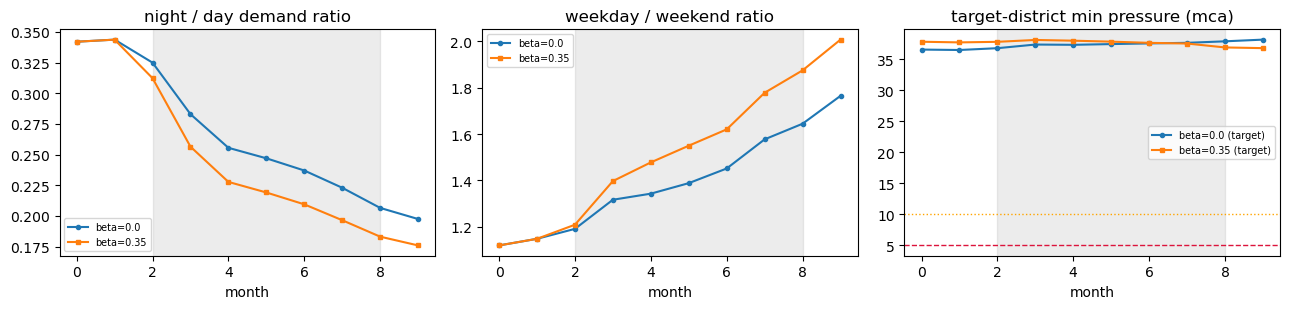

In [30]:
def night_day(r, nodes, month):
    st = _steps(r); w = week_profile(r, month, nodes).reshape(7, st)
    h = (np.arange(st) + .5) * r["time"]["resolution_h"]
    night, day = w[:, (h < 5)].mean(), w[:, (h >= 9) & (h < 17)].mean()
    return night / day, w[:5].mean() / max(w[5:].mean(), 1e-9)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for r, mk in ((res_shp, "o"), (res_lvl, "s")):
    ms = range(r["time"]["n_months"])
    nd = [night_day(r, _nodes(r), m) for m in ms]
    axes[0].plot(ms, [x[0] for x in nd], marker=mk, ms=3, label=f"beta={r['beta']}")
    axes[1].plot(ms, [x[1] for x in nd], marker=mk, ms=3, label=f"beta={r['beta']}")
    p = r["pressures"].assign(month=r["demand"]["month"].to_numpy())
    junc = [c for c in p.columns if c in NODE2DIST]
    axes[2].plot(p.groupby("month")[_nodes(r)].min().min(axis=1), marker=mk, ms=3,
                 label=f"beta={r['beta']} (target)")
for ax, ttl in zip(axes, ["night / day demand ratio", "weekday / weekend ratio",
                          "target-district min pressure (mca)"]):
    ax.axvspan(_onset(res_lvl), _end(res_lvl), color="grey", alpha=.15, zorder=0)
    ax.set(xlabel="month", title=ttl); ax.legend(fontsize=7)
axes[2].axhline(5.0, color="crimson", ls="--", lw=1)
axes[2].axhline(10.0, color="orange", ls=":", lw=1)
plt.tight_layout()
plt.show()

## 7. Does the signature survive the scaler?

Per-client MinMax fitted on `reference_months` is affine, so it cannot remove a *shape* change.
`shape_shift = 1 - corr(week_before, week_after)` on the normalised series isolates exactly that.

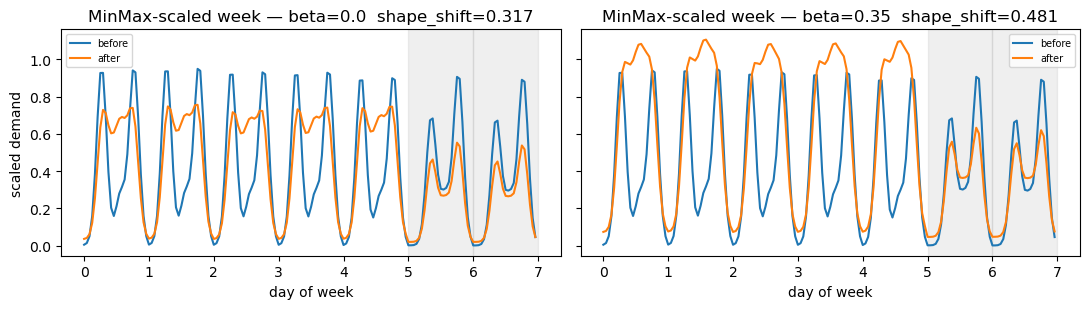

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, r in zip(axes, (res_shp, res_lvl)):
    ph = phases(r)
    a, b = (week_profile(r, ph["before"], scaled=True),
            week_profile(r, ph["after"], scaled=True))
    ax.plot(np.arange(len(a)) / _steps(r), a, lw=1.5, label="before")
    ax.plot(np.arange(len(b)) / _steps(r), b, lw=1.5, label="after")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(xlabel="day of week", title=f"MinMax-scaled week — beta={r['beta']}  "
                                       f"shape_shift={1 - np.corrcoef(a, b)[0, 1]:.3f}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("scaled demand")
plt.tight_layout()
plt.show()

## 8. Sweep — maps x drift x beta

In [32]:
def metrics(r):
    ph = phases(r)
    d, p = r["demand"], r["pressures"].assign(month=r["demand"]["month"].to_numpy())
    junc = [c for c in p.columns if c in NODE2DIST]
    nd_b, nd_a = night_day(r, _nodes(r), ph["before"]), night_day(r, _nodes(r), ph["after"])
    mb = d.loc[d["month"] == ph["before"], _nodes(r)].sum(axis=1).mean()
    ma = d.loc[d["month"] == ph["after"],  _nodes(r)].sum(axis=1).mean()
    a, b = (week_profile(r, ph["before"], scaled=True),
            week_profile(r, ph["after"], scaled=True))
    return {"map": r["map"], "beta": r["beta"], "calibration": r["calibration"],
            "d_mean_%": 100 * (ma / mb - 1),
            "night_day_before": nd_b[0], "night_day_after": nd_a[0],
            "wk_we_before": nd_b[1], "wk_we_after": nd_a[1],
            "shape_shift": 1 - np.corrcoef(a, b)[0, 1],
            "pmin_after": p.loc[p["month"] == ph["after"], junc].to_numpy().min(),
            "pmin_all": p[junc].to_numpy().min()}


MAPS = ["LR_LR_LR_LR_LR", "LR_LM_LC_LR_LR", "LR_LM_LM_LR_LC"]
DRIFTS = {
    "D -> commercial": [{"tgt_district": "District_D", "to_income": "low",
                         "to_land_use": "commercial"}],
    "D -> industrial": [{"tgt_district": "District_D", "to_income": "low",
                         "to_land_use": "industrial"}],
    "A+D -> industrial": [{"tgt_district": "District_A", "to_income": "low",
                           "to_land_use": "industrial"},
                          {"tgt_district": "District_D", "to_income": "low",
                           "to_land_use": "industrial"}],
}
BETAS = [0.0, 0.35]

rows, worlds = [], {}
for mp, (dn, dr), b in itertools.product(MAPS, DRIFTS.items(), BETAS):
    try:
        r = run_world(mp, dr, beta=b)
        worlds[(mp, dn, b)] = r
        rows.append({**metrics(r), "drift": dn})
    except Exception as e:
        rows.append({"map": mp, "drift": dn, "beta": b, "error": type(e).__name__})
        print("FAIL", mp, dn, b, e)

sweep = pd.DataFrame(rows)
sweep["V3_pass"] = sweep["pmin_all"] >= 5.0
sweep.round(3)

,map,beta,calibration,d_mean_%,night_day_before,night_day_after,wk_we_before,wk_we_after,shape_shift,pmin_after,pmin_all,drift,V3_pass
0,LR_LR_LR_LR_LR,0.00,1.000,2.178,0.344,0.197,1.148,1.765,0.317,34.380001,32.542999,D -> commercial,True
1,LR_LR_LR_LR_LR,0.35,1.000,38.921,0.344,0.176,1.148,2.007,0.481,32.981998,32.362999,D -> commercial,True
2,LR_LR_LR_LR_LR,0.00,1.000,2.275,0.344,0.542,1.148,1.169,0.022,34.590000,32.542999,D -> industrial,True
3,LR_LR_LR_LR_LR,0.35,1.000,68.829,0.344,0.602,1.148,1.175,0.082,32.310001,32.039001,D -> industrial,True
4,LR_LR_LR_LR_LR,0.00,1.000,1.879,0.343,0.583,1.142,1.182,0.055,35.250000,32.542999,A+D -> industrial,True
5,LR_LR_LR_LR_LR,0.35,1.000,85.182,0.343,0.630,1.142,1.189,0.163,31.881001,31.670000,A+D -> industrial,True
6,LR_LM_LC_LR_LR,0.00,1.000,2.178,0.344,0.197,1.148,1.765,0.317,38.159000,36.492001,D -> commercial,True
7,LR_LM_LC_LR_LR,0.35,0.820,38.921,0.344,0.176,1.148,2.007,0.481,36.808998,36.808998,D -> commercial,True
8,LR_LM_LC_LR_LR,0.00,1.000,2.275,0.344,0.542,1.148,1.169,0.022,38.387001,36.492001,D -> industrial,True
9,LR_LM_LC_LR_LR,0.35,0.820,68.829,0.344,0.602,1.148,1.175,0.082,37.597000,37.498001,D -> industrial,True


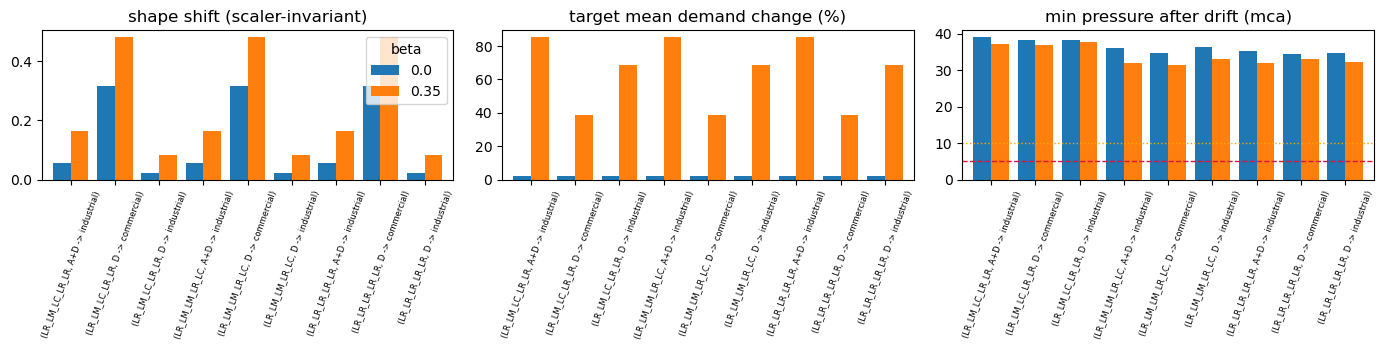

night_day_after        shape_shift         \
beta                                        0.00   0.35        0.00   0.35   
map            drift                                                         
LR_LM_LC_LR_LR A+D -> industrial           0.583  0.630       0.055  0.163   
               D -> commercial             0.197  0.176       0.317  0.481   
               D -> industrial             0.542  0.602       0.022  0.082   
LR_LM_LM_LR_LC A+D -> industrial           0.583  0.630       0.055  0.163   
               D -> commercial             0.197  0.176       0.317  0.481   
               D -> industrial             0.542  0.602       0.022  0.082   
LR_LR_LR_LR_LR A+D -> industrial           0.583  0.630       0.055  0.163   
               D -> commercial             0.197  0.176       0.317  0.481   
               D -> industrial             0.542  0.602       0.022  0.082   

                                 wk_we_after         
beta                                    0.00   0.35  
map            drift                                 
LR_LM_LC_LR_LR A+D -> industrial       1.182  1.189  
               D -> commercial         1.765  2.007  
               D -> industrial         1.169  1.175  
LR_LM_LM_LR_LC A+D -> industrial       1.182  1.189  
               D -> commercial         1.765  2.007  
               D -> industrial         1.169  1.175  
LR_LR_LR_LR_LR A+D -> industrial       1.182  1.189  
               D -> commercial         1.765  2.007  
               D -> industrial         1.169  1.175

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, ttl in zip(axes, ["shape_shift", "d_mean_%", "pmin_after"],
                        ["shape shift (scaler-invariant)", "target mean demand change (%)",
                         "min pressure after drift (mca)"]):
    sweep.pivot_table(index=["map", "drift"], columns="beta", values=col).plot.bar(
        ax=ax, width=.8, legend=(col == "shape_shift"))
    ax.set(title=ttl, xlabel="")
    ax.tick_params(axis="x", labelsize=6, rotation=70)
axes[2].axhline(5.0, color="crimson", ls="--", lw=1)
axes[2].axhline(10.0, color="orange", ls=":", lw=1)
plt.tight_layout()
plt.show()
sweep.pivot_table(index=["map", "drift"], columns="beta",
                  values=["night_day_after", "wk_we_after", "shape_shift"]).round(3)

In [34]:
def band_report(r, lo=10.0, hi=50.0):
    p = r["pressures"]
    v = p[[c for c in p.columns if c in NODE2DIST]].to_numpy()
    inside = ((v >= lo) & (v <= hi)).mean()
    return {"pmin": v.min(), "pmax": v.max(), "inside_%": 100 * inside,
            "V3": v.min() >= 5.0, "V4": inside >= 0.98}

pd.DataFrame([{"map": k[0], "drift": k[1], "beta": k[2], **band_report(r)}
              for k, r in worlds.items()]).round(2)

,map,drift,beta,pmin,pmax,inside_%,V3,V4
0,LR_LR_LR_LR_LR,D -> commercial,0.00,32.540001,48.470001,100.0,True,True
1,LR_LR_LR_LR_LR,D -> commercial,0.35,32.360001,48.470001,100.0,True,True
2,LR_LR_LR_LR_LR,D -> industrial,0.00,32.540001,48.470001,100.0,True,True
3,LR_LR_LR_LR_LR,D -> industrial,0.35,32.040001,48.470001,100.0,True,True
4,LR_LR_LR_LR_LR,A+D -> industrial,0.00,32.540001,48.470001,100.0,True,True
5,LR_LR_LR_LR_LR,A+D -> industrial,0.35,31.670000,48.470001,100.0,True,True
6,LR_LM_LC_LR_LR,D -> commercial,0.00,36.490002,48.450001,100.0,True,True
7,LR_LM_LC_LR_LR,D -> commercial,0.35,36.810001,48.439999,100.0,True,True
8,LR_LM_LC_LR_LR,D -> industrial,0.00,36.490002,48.450001,100.0,True,True
9,LR_LM_LC_LR_LR,D -> industrial,0.35,37.500000,48.439999,100.0,True,True


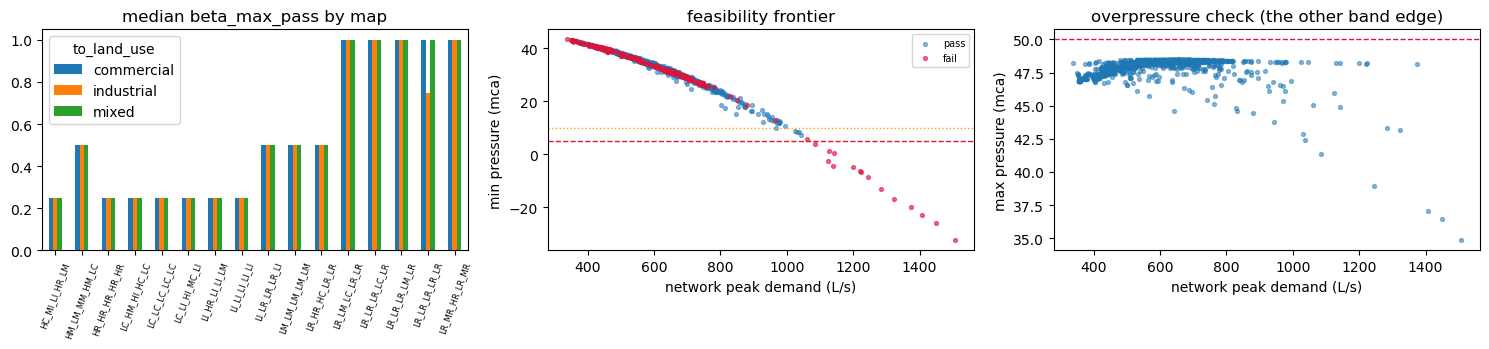

[08/28/26 21:15:57] WARNING  EPANET warning 6 - At   0:00:00, system has negative pressures -        ]8;id=707229;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py\toolkit.py]8;;\:]8;id=233914;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py#147\147]8;;\
                             negative pressures occurred at one or more junctions with positive                    
                             demand                                                                                

                    WARNING  Warnings were issued during simulation                                      ]8;id=484264;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py\io.py]8;;\:]8;id=185623;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py#2861\2861]8;;\

10/336 combos  1.3 min  eta 43.4 min


[08/28/26 21:16:53] WARNING  EPANET warning 6 - At   0:00:00, system has negative pressures -        ]8;id=540263;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py\toolkit.py]8;;\:]8;id=649661;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py#147\147]8;;\
                             negative pressures occurred at one or more junctions with positive                    
                             demand                                                                                

                    WARNING  Warnings were issued during simulation                                      ]8;id=790595;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py\io.py]8;;\:]8;id=239367;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py#2861\2861]8;;\

...

20/336 combos  2.6 min  eta 41.5 min


[08/28/26 21:18:02] WARNING  EPANET warning 6 - At   0:00:00, system has negative pressures -        ]8;id=802561;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py\toolkit.py]8;;\:]8;id=32797;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\toolkit.py#147\147]8;;\
                             negative pressures occurred at one or more junctions with positive                    
                             demand                                                                                

                    WARNING  Warnings were issued during simulation                                      ]8;id=415684;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py\io.py]8;;\:]8;id=220237;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\wntr\epanet\io.py#2861\2861]8;;\

30/336 combos  4.1 min  eta 42.0 min


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 get_ipython().run_line_magic('run', '-i landuse_stress.py')                                  │
│ ❱ 2 results = stress_sweep()                                                                     │
│   3 edge = report(results)                                                                       │
│   4 plot_report(results, edge)                                                                   │
│   5                                                                                              │
│                                                                                                  │
│ C:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\notebooks\prospection\landuse_stress.py:185 │
│ in stress_sweep                                                                                  │
│                                                                                                  │
│   182 │   │   │   row = {"map": mp, "targets": label, "n_targets": len(tgts), "to_land_use": l   │
│   183 │   │   │   │      "to_income": inc, "anchor_scale": anc, "beta": beta}                    │
│   184 │   │   │   try:                                                                           │
│ ❱ 185 │   │   │   │   row |= check_world(run_stress(mp, drifts, beta, anc, cfg))                 │
│   186 │   │   │   except Exception as e:                                                         │
│   187 │   │   │   │   row |= {"passed": False, "fail": f"EXC:{type(e).__name__}",                │
│   188 │   │   │   │   │   │   "error": str(e)[:160]}                                             │
│                                                                                                  │
│ C:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\notebooks\prospection\landuse_stress.py:76  │
│ in run_stress                                                                                    │
│                                                                                                  │
│    73 │   dem = poc_synthesize_demands(tl, pat, time, cfg["sim_seed"])                           │
│    74 │   if len(sched):                                                                         │
│    75 │   │   dem = apply_drift_ramp(dem, sched, pat, time)                                      │
│ ❱  76 │   pres, _, dsim = run_hydraulics(wn, dem)                                                │
│    77 │                                                                                          │
│    78 │   tgt_nodes = {n for d in drifts for n in DISTRICTS["districts"][d["tgt_district"]]}     │
│    79 │   last = cfg["n_months"] - 1                                                             │
│                                                                                                  │
│ C:\Users\arthu\USPy\10_Mestrado\experiments\fedWater\src\fedwater\pipelines\hydraulics\nodes.py: │
│ 34 in run_hydraulics                                                                             │
│                                                                                                  │
│   31 │   │   junction.demand_timeseries_list[0].base_value = UNIT_BASE_SI                        │
│   32 │   │   junction.demand_timeseries_list[0].pattern_name = pattern_name                      │
│   33 │                                                                                           │
│ ❱ 34 │   results = wntr.sim.EpanetSimulator(wn).run_sim()                                        │
│   35 │                                                                                           │
│   36 │   pressures = results.node["pressure"]              

In [39]:
%run -i landuse_stress.py
results = stress_sweep()
edge = report(results)
plot_report(results, edge)

In [41]:
import logging; logging.getLogger("wntr").setLevel(logging.ERROR)

bad = results[results["pmin"] < 5]
print(len(bad), "runs below the floor")
print(bad.groupby(["to_land_use", "beta"]).size().to_string())
print(bad[["map", "targets", "to_land_use", "beta", "peak_lps", "pmin", "drifted_%"]]
      .sort_values("pmin").head(10).to_string(index=False))

15 runs below the floor
to_land_use  beta
commercial   0.50    1
             0.75    3
             1.00    1
industrial   0.75    3
             1.00    6
mixed        1.00    1
           map   targets to_land_use  beta    peak_lps       pmin  drifted_%
LR_LR_LR_LR_LR A+B+C+D+E  industrial  0.75 1505.527439 -32.571514  62.831858
LR_LM_LC_LR_LR A+B+C+D+E  industrial  1.00 1449.243160 -26.030151  62.831858
LR_MR_HR_LR_MR A+B+C+D+E  industrial  1.00 1407.337246 -22.837975  62.831858
LR_LR_LR_LM_LR A+B+C+D+E  commercial  0.75 1373.743045 -20.139542  62.831858
LR_LR_LR_LR_LR         B  industrial  1.00 1321.842761 -16.884874  68.965517
LR_LR_LR_LR_LR       A+D  industrial  1.00 1282.910442 -13.311070  66.666667
LR_LR_LR_LM_LR A+B+C+D+E  industrial  0.75 1245.766835  -8.696401  62.831858
LR_LR_LR_LR_LR A+B+C+D+E       mixed  1.00 1223.402327  -6.648486  62.831858
LR_MR_HR_LR_MR A+B+C+D+E  commercial  1.00 1219.467197  -6.226552  62.831858
LR_LR_LR_LC_LR A+B+C+D+E  commercial  0.75 1198.46

## 9. Read-out

- `beta=0` is the honest test of the idea: volume-neutral, so any `shape_shift` is pure
  temporal signature. If it is large there, land use is legible without touching the level.
- `night_day` should *rise* on `-> industrial` (24/7 draw lifts the night minimum) and *fall*
  on `-> commercial`. Opposite-signed, physically interpretable drifts.
- `wk_we` should rise sharply on `-> commercial` — a weekly gate the 84 x 2h FL window
  resolves in full.
- Watch `pmin_after` at `beta=0.5`: industrial is the demanding case. If V3 breaks, lower
  `beta` or `anchor_scale` before changing the sector table.
- Also check the *upper* pressure band: a commercial district at 3am draws almost nothing,
  so night pressures rise toward static head — the opposite failure mode to the usual one.